# 01 · Quickstart: your first nowcast in ten lines

**Nowcasting** is the prediction of the present, the very recent past and the near
future of a low-frequency macroeconomic variable (here, quarterly GDP) using the
higher-frequency indicators that are published *before* it (Giannone, Reichlin &
Small, 2008; Bańbura, Giannone & Reichlin, 2011). Statistical offices publish GDP
about two months after the end of the quarter; industrial production, retail sales,
confidence surveys or financial prices arrive much earlier. A nowcasting model turns
that flow of monthly information into a timely estimate of the current quarter.

This notebook shows the shortest route through `nowcastbox`:

1. load the shipped Brazilian panel (`load_brazil_nowcast`, 99 series from BCB, IBGE
   and IPEA);
2. call `nb.nowcast(...)` — which transforms the data, picks the number of factors with
   the Bai & Ng (2002) criteria and estimates a mixed-frequency dynamic factor model by
   EM (Bańbura & Modugno, 2014);
3. read the nowcast, its uncertainty and a chart.

Everything runs offline in well under a minute.

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))  # the examples/ folder (helpers in examples/utils)

from utils import SEED, display, md, pct, setup, show

setup()

## The ten lines

`preprocess=True` applies the stationarity transformation recorded in the dataset
legend (quarter-on-quarter growth for GDP, monthly log-differences for activity
indices, year-on-year changes for non-seasonally-adjusted series, ...), replaces
extreme outliers of the predictors and drops series with too many missing values. `density=True` adds
a predictive distribution (innovation I5) to the point nowcast.

In [2]:
import nowcastbox as nb

ds = nb.load_brazil_nowcast()  # levels, monthly grid, quarterly GDP in the 3rd month
res = nb.nowcast(
    ds.data,
    target="pib",  # GDP volume index, SA -> QoQ growth after preprocessing
    method="em",  # Bańbura & Modugno (2014) mixed-frequency DFM
    preprocess=True,  # legend transformations + outliers + sparse series (not the target)
    density=True,  # 68 % / 90 % intervals of the predictive distribution
    random_state=SEED,
)
print(res.summary())

                        Nowcast Results: MixedFreqDFM
Target:                 pib (quarterly)
Sample:                 2003-01 .. 2026-09
Series:                 86
Factors:                5
Log-likelihood:         -22979.1958
Iterations:             9
Converged:              True
------------------------------------------------------------------------------
Model parameters
  n_factors             5
  factor_lags           1
  blocks                -
  idiosyncratic         ar1
  max_iter              500
  tol                   0.0001
  init                  pca
  obs_noise_var         0.0001
  filter_method         auto
  df                    -
  outliers              none
  outlier_threshold     4.0000
  exclude_periods       -
  covid                 none
  covid_window          ('2020-03', '2021-12')
  long_run_mean         constant
  long_run_series       -
  long_run_variance     -
------------------------------------------------------------------------------
Factor dynamics
  

The summary reports the sample, the number of factors chosen by the Bai-Ng `IC2`
criterion, the EM log-likelihood and convergence, and the last estimates: `in_sample`
is the model's fitted value for quarters in which GDP is already published,
`out_of_sample` the **nowcast** (current quarter) and **forecast** (next quarter).

## The nowcast table

`res.nowcast` is a regular `pandas.DataFrame` indexed by quarters. The target is the
quarter-on-quarter growth rate of seasonally adjusted GDP, stored as a fraction
(0.01 = 1 %).

In [3]:
table = res.nowcast[["observed", "in_sample", "out_of_sample", "lower_90", "upper_90"]]
display(table.tail(6))

,observed,in_sample,out_of_sample,lower_90,upper_90
period,,,,,
2025Q3,0.0011,0.0015,NaN,NaN,NaN
2025Q4,0.0025,-0.0044,NaN,NaN,NaN
2026Q1,0.0107,0.0083,NaN,NaN,NaN
2026Q2,0.0048,0.0056,NaN,NaN,NaN
2026Q3,NaN,NaN,-0.0051,-0.0242,0.0140
2026Q4,NaN,NaN,0.0026,-0.0220,0.0272


In [4]:
last_obs = res.observed.dropna()  # published GDP growth
period = last_obs.index[-1] + 1  # the first quarter without a GDP release
current = res.get_nowcast()  # default period = first quarter after the last release
row = res.nowcast.loc[period]
md(
    f"**Nowcast of Brazilian GDP growth for {period}: {pct(current)} QoQ** "
    f"(90 % interval {pct(row['lower_90'])} to {pct(row['upper_90'])}). "
    f"The last published quarter is {last_obs.index[-1]} with {pct(last_obs.iloc[-1])}; "
    f"the model used {res.n_factors} factors selected by Bai & Ng's "
    f"{res.info['selection'].criterion}."
)

**Nowcast of Brazilian GDP growth for 2026Q3: -0.51% QoQ** (90 % interval -2.42% to 1.40%). The last published quarter is 2026Q2 with 0.48%; the model used 5 factors selected by Bai & Ng's IC2.

**Economic reading.** A quarter-on-quarter rate close to zero with a 90 % band
straddling zero says that the monthly indicators released so far (industrial
production, retail, services, credit, prices, Focus expectations) are consistent with
a stagnating economy, but that the information set is still too thin to rule out a
mild expansion or contraction. The width of the band is the honest message: the
typical revision of a nowcast between the start of a quarter and the GDP release is of
the same order as the growth rate itself. Notebooks 07 and 13 show how the estimate
moves as data arrive and how good the bands are historically.

## A picture

`res.plot("forecast")` draws the published series, the in-sample fit and the
out-of-sample nowcast with its bands. Plots are interactive Plotly figures by default;
the examples use `backend="matplotlib"` so the outputs render as static images on
GitHub.

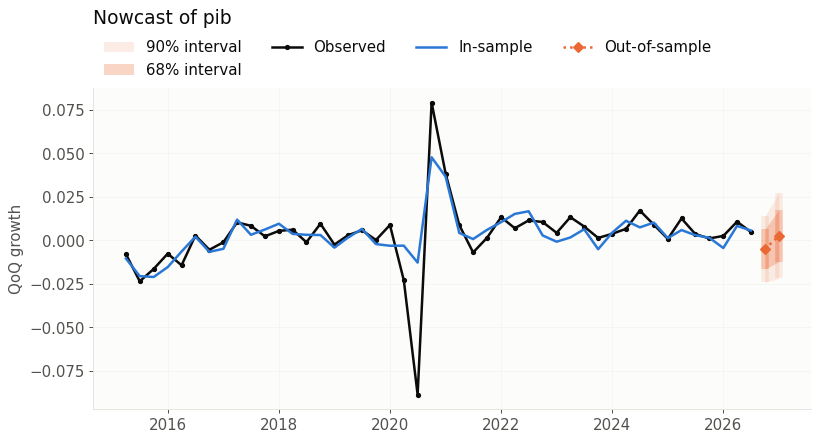

In [5]:
fig = res.plot("forecast", backend="matplotlib", start="2015Q1", ylabel="QoQ growth")
show(fig, "01_forecast")

Outside 2020 the in-sample fit tracks the broad cycle (the 2015–2016 recession, the
slow recovery, the 2021–2022 rebound) but not every quarterly wiggle: a factor model
extracts the *common* component of the panel, and part of quarterly GDP growth is
idiosyncratic (agriculture, inventories, statistical noise).

> **Note — the target is never cleaned by `nb.nowcast`.** `preprocess=True` runs
> `prepare_panel` (outliers, interior gaps, sparse series) on the predictors, but the
> target is only transformed: the 2020 contraction and rebound enter the model and the
> `observed` column as published (`preprocess={"clean_target": True}` would winsorise
> them too). The cell below checks it. Notebook 10 compares ways of dealing with the
> pandemic quarters (robust EM with Student-t errors, pandemic dummies, outlier
> detection inside the EM).

In [6]:
import pandas as pd

published = nb.apply_transforms(ds.data, ds.transform).to_native("pib")
compare = pd.DataFrame({"published": published, "used by the model": res.observed})
display(compare.loc["2020Q1":"2020Q4"].map(pct))

,published,used by the model
period,,
2020Q1,-2.29%,-2.29%
2020Q2,-8.88%,-8.88%
2020Q3,7.92%,7.92%
2020Q4,3.84%,3.84%


## The object-oriented route

`nb.nowcast` is a thin convenience wrapper. The same model can be built explicitly,
which gives full control over every option:

In [7]:
panel = nb.prepare_panel(ds.data, ds.transform)  # cleans every series, target included
raw_target = nb.apply_transforms(ds.data, ds.transform).data["pib"]
panel = panel.with_data(panel.data.assign(pib=raw_target.reindex(panel.index)))  # as nb.nowcast
model = nb.MixedFreqDFM(n_factors=res.n_factors, factor_lags=1, max_iter=500, tol=1e-4)
res_oo = model.fit(panel, target="pib")
md(
    f"Object-oriented nowcast for {period}: **{pct(res_oo.get_nowcast(period))}** "
    f"(same specification, {res_oo.n_iter} EM iterations)."
)

Object-oriented nowcast for 2026Q3: **-0.51%** (same specification, 9 EM iterations).

## Where to go next

| Notebook | Topic |
|---|---|
| 02 | data preparation: transformations, outliers, ragged edges |
| 03–05 | the classical models: two-step DFM (GRS 2008), Bai-Ng, EM with blocks (NY Fed) |
| 06–09 | Brazil: vintages, news, pseudo real-time evaluation, live data |
| 10–15 | robustness, production pipeline, reports, density, high frequency, comparisons |

### References

* Bai, J. & Ng, S. (2002). Determining the number of factors in approximate factor
  models. *Econometrica*, 70(1), 191–221.
* Bańbura, M., Giannone, D. & Reichlin, L. (2011). Nowcasting. In *Oxford Handbook of
  Economic Forecasting*, 193–224.
* Bańbura, M. & Modugno, M. (2014). Maximum likelihood estimation of factor models on
  datasets with arbitrary pattern of missing data. *Journal of Applied Econometrics*,
  29(1), 133–160.
* Giannone, D., Reichlin, L. & Small, D. (2008). Nowcasting: the real-time
  informational content of macroeconomic data. *Journal of Monetary Economics*, 55(4),
  665–676.